
# 🧠 Xarxa Neuronal FNN vs CNN - Classificació

---
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*6YhvuUHE0LPHEsqU_Cis9w.png)

## 🎯 Objectius

* Aquest notebook pretén mostrar un primer exemple utlitzant el Framework Keras per la realització d'una xarxa neuronal aplicada a una classificació de 2 classes.

## 📦 Datasets

Fashion-MINST és un conjunt de dades format per 70.000 imatges a escala de grisos d'articles de moda de [Zalando](https://github.com/zalandoresearch/fashion-mnist).
És un dataset molt utilitzat per evaluar algoirsmes d'aprenentatge automàtic (Machine Learning)
60.000 imatges d'entenament i 10.000 de test, dividides en 10 categories.

* 0: T-shirt/top
* 1: Trouser
* 2: Pullover
* 3: Dress
* 4: Coat
* 5: Sandal
* 6: Shirt
* 7: Sneaker
* 8: Bag
* 9: Ankle boot



## 🟦 0. Import Classes

In [3]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 740.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 22.4 MB/s eta 0:00:00


In [4]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,confusion_matrix, accuracy_score, precision_score,
    recall_score, precision_recall_fscore_support, f1_score, roc_curve, auc, precision_recall_curve
)

import tensorflow as tf

target_dict = {
 0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot',
}

#class_names = list['t-shirt/top', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## 🟦 1. Load Data

Carreguem el dataset

In [5]:
print("Carreguem el dataset fashion MNIST")

fashion_mnist = tf.keras.datasets.fashion_mnist
(train_img, train_lbl), (test_img, test_lbl) = fashion_mnist.load_data()
#print(df.DESCR)

print(f'Tenim un total de {train_lbl.shape[0]} imatges d\'entrenament')
print(f'Tenim un total de {test_lbl.shape[0]} imatges de test')
print('Shape de les característiques IMG:', train_img.shape)
print('Shape de les característiques LABEL:', train_lbl.shape)



Carreguem el dataset fashion MNIST
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tenim un total de 60000 imatges d'entrenament
Tenim un total de 10000 imatges de test
Shape de les característiques IMG: (60000, 28, 28)
Shape de les característiques LABEL: (60000,)


Text(0.5, 1.0, 'Ankle boot')

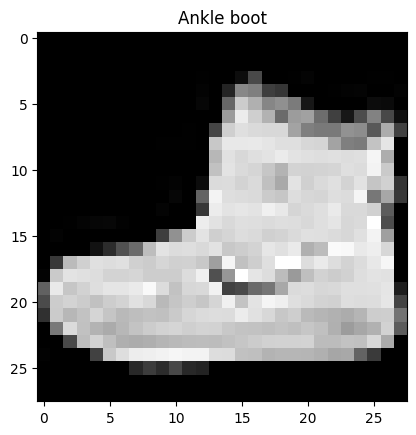

In [6]:
plt.imshow(train_img[0], cmap="gray")
plt.title( target_dict[(train_lbl[0])] )

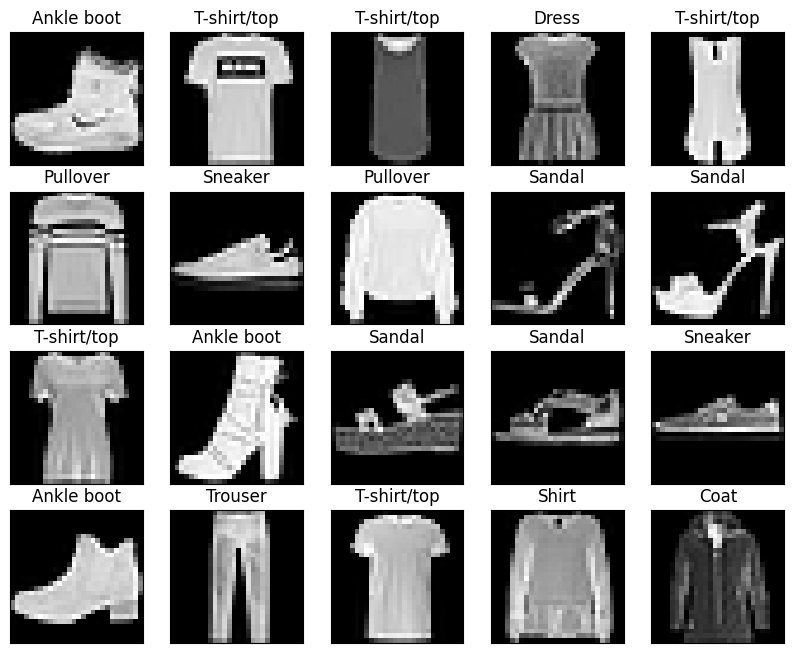

In [7]:
random_indices = np.random.choice(len(train_img), 20, replace=False)

plt.figure(figsize=(10,10))

for i, idx in enumerate(random_indices):
    plt.subplot(5,5,i+1)
    plt.imshow(train_img[i], cmap="gray")
    plt.title( target_dict[(train_lbl[i]) ])
    plt.xticks([])
    plt.yticks([])



In [8]:
train_img[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [9]:
train_lbl[0]

np.uint8(9)

In [10]:
## Passem de [0-1] (MinMax Scaler, però com que sabem que els píxels van de 0-255)

train_img_sc = train_img.astype("float32") / 255.0
test_img_sc = test_img.astype("float32") / 255.0

#No tranformem train_lbl perquè és np.uint8.
#train_lbl = train_lbl.astype(np.int32)
#test_lbl = test_lbl.astype(np.int32)

## 🟦 2 Construcció i entrenament dels models

### 🟦 2.1 Model FNN

#### Definició

In [11]:
fc_model = tf.keras.Sequential()
fc_model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
fc_model.add(tf.keras.layers.Dense(128, activation='relu'))
fc_model.add(tf.keras.layers.Dense(64, activation = 'relu'))
fc_model.add(tf.keras.layers.Dense(10))
fc_model.add(tf.keras.layers.Softmax())

#fc_model = models.Sequential([
#    layers.Input(shape = (28, 28)),
#    layers.Flatten(),
#    layers.Dense(128, activation = 'relu'),
#    layers.Dense(10),
#    layers.Softmax()
#])

fc_model.summary()

fc_model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Entrenament

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

#print("X_train:", X_train.shape)
#print("y_train:", y_train.shape)
#print("X_val:", X_val.shape)
#print("y_val:", y_val.shape)
#print("y_val_oh:", y_val_oh.shape)


#history = fc_model.fit(
fc_model.fit(
    train_img_sc, train_lbl,
    validation_split=0.2,
    epochs=10, #50
    batch_size=16,
    callbacks=[early_stop],
    #verbose=0
)

#print("Epochs:", len(history.history["loss"]))

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7754 - loss: 0.6323 - val_accuracy: 0.8497 - val_loss: 0.4199
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8583 - loss: 0.3833 - val_accuracy: 0.8697 - val_loss: 0.3573
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8759 - loss: 0.3343 - val_accuracy: 0.8671 - val_loss: 0.3659
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8842 - loss: 0.3120 - val_accuracy: 0.8841 - val_loss: 0.3285
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8887 - loss: 0.2983 - val_accuracy: 0.8737 - val_loss: 0.3559
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8965 - loss: 0.2795 - val_accuracy: 0.8826 - val_loss: 0.3316
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8981 - loss: 0.2702 - val_accuracy: 0.8773 - val_loss: 0.3504
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9047 - loss: 0.2566 - 

#### Avaluació

In [13]:
_ = fc_model.evaluate(test_img_sc, test_lbl, verbose = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.8767 - loss: 0.3527


### 🟦 2.2. Model CNN

#### Definició

In [19]:
cnn_model = tf.keras.Sequential()

#extracció de característiques
cnn_model.add(tf.keras.layers.Input(shape = (28, 28, 1)))
cnn_model.add(tf.keras.layers.Conv2D(32, (3, 3),padding='same', activation = 'relu'))
cnn_model.add(tf.keras.layers.MaxPooling2D((2, 2)))
cnn_model.add(tf.keras.layers.Conv2D(64, (3, 3),padding='same', activation = 'relu'))
cnn_model.add(tf.keras.layers.MaxPooling2D((2, 2)))
cnn_model.add(tf.keras.layers.Conv2D(128, (3, 3),padding='same', activation = 'relu'))
#cnn_model.add(tf.keras.layers.MaxPooling2D((2, 2)))
cnn_model.add(tf.keras.layers.GlobalAveragePooling2D())
#apartat classifiació
cnn_model.add(tf.keras.layers.Flatten())
cnn_model.add(tf.keras.layers.Dense(128, activation = 'relu'))
cnn_model.add(tf.keras.layers.Dropout(0.25))
cnn_model.add(tf.keras.layers.Dense(64, activation = 'relu'))
cnn_model.add(tf.keras.layers.Dropout(0.25))
cnn_model.add(tf.keras.layers.Dense(10))
cnn_model.add(tf.keras.layers.Softmax())

#cnn_model = models.Sequential([
#    #extracció de característiques
#    layers.Input(shape = (28, 28, 1)),
#    layers.Conv2D(24, (3, 3), activation = 'relu'),
#    layers.MaxPooling2D((2, 2)),
#    layers.Conv2D(48, (3, 3), activation = 'relu'),
#    layers.MaxPooling2D((2, 2)),
#    layers.Conv2D(48, (3, 3), activation = 'relu'),
#    # apartat de classificació
#    layers.Flatten(),
#    layers.Dense(48, activation = 'relu'),
#    layers.Dense(10),
#    layers.Softmax()
#])

cnn_model.summary()

cnn_model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_3 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,090 (461.29 KB)

 Trainable params: 118,090 (461.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Entrenament

In [20]:
#history_cnn = cnn_model.fit(
#    train_img_sc, train_lbl,
#    validation_split=0.2,
#    epochs=50,
#    batch_size=16,
#    callbacks=[early_stop],
#    verbose=0
#)
cnn_model.fit(
    train_img_sc, train_lbl,
    validation_split=0.2,
    epochs=10, #50
    #batch_size=16,
    #callbacks=[early_stop],
)

#print("Epochs:", len(history_cnn.history["loss"]))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5081 - loss: 1.2598 - val_accuracy: 0.7675 - val_loss: 0.5900
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.7839 - loss: 0.5829 - val_accuracy: 0.8393 - val_loss: 0.4321
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8254 - loss: 0.4914 - val_accuracy: 0.8481 - val_loss: 0.4021
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8544 - loss: 0.4079 - val_accuracy: 0.8712 - val_loss: 0.3457
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8691 - loss: 0.3636 - val_accuracy: 0.8864 - val_loss: 0.3040
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8814 - loss: 0.3314 - val_accuracy: 0.8931 - val_loss: 0.2968
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8892 - loss: 0.3092 - val_accuracy: 0.8933 - val_loss: 0.2965
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9003 -

#### Avaluació

In [21]:
test_loss,test_acc = cnn_model.evaluate(test_img_sc, test_lbl, verbose = 1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8983 - loss: 0.2782
Test loss: 0.2883
Test accuracy: 0.8960


## 🟦 4. Valoració

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


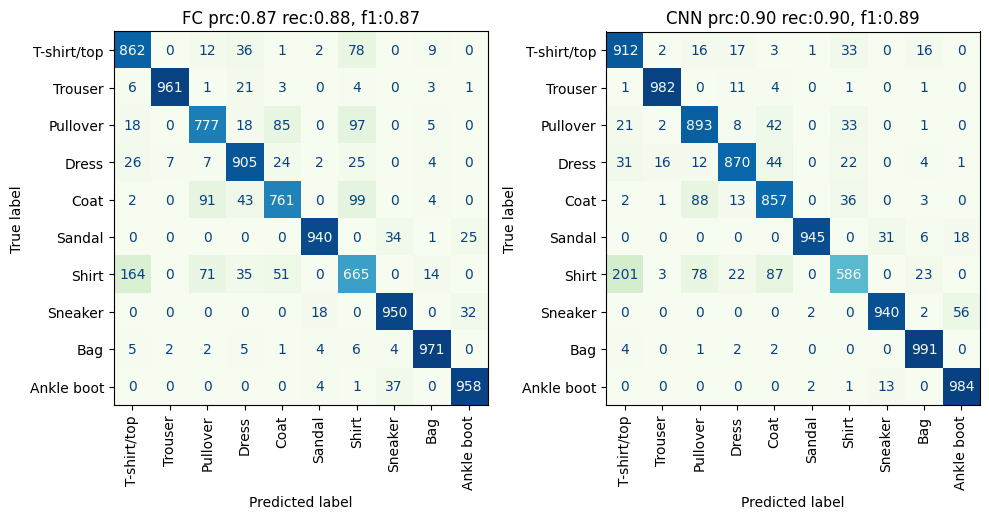

In [22]:
fc_proba = fc_model.predict(test_img_sc)
fc_preds = np.argmax(fc_proba, axis=1)

cnn_proba = cnn_model.predict(test_img_sc)
cnn_preds = np.argmax(cnn_proba, axis=1)
#cnn_proba[0]
#cnn_pred[0]

models = [
    ("FC", fc_preds),
    ("CNN", cnn_preds)
]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
for axi, (model_name, preds) in zip(axs.flatten(), models):
    prc, rec, f1, _ = precision_recall_fscore_support(test_lbl, preds, average = 'macro')
    axi.set_title(f"{model_name} prc:{prc:.2f} rec:{rec:.2f}, f1:{f1:.2f}");
    ConfusionMatrixDisplay.from_predictions(
        test_lbl,
        preds,
        normalize = None,
        values_format = 'd',
        display_labels = list(target_dict.values()),
        ax = axi,
        xticks_rotation = 90,
        cmap = 'GnBu',
        colorbar = False
    )
plt.tight_layout();